In [3]:
import pandas as pd
# Load the uploaded CSVs
otp_2021 = pd.read_csv("/Users/kathypresto/Desktop/trimet/Big_Data/Final/chi tests/otp_2021.csv", index_col="ROUTE_NUMBER")
otp_2022 = pd.read_csv("/Users/kathypresto/Desktop/trimet/Big_Data/Final/chi tests/otp_2022.csv", index_col="ROUTE_NUMBER")
otp_2023 = pd.read_csv("/Users/kathypresto/Desktop/trimet/Big_Data/Final/chi tests/otp_2023.csv", index_col="ROUTE_NUMBER")

# Keep only the OTP_Percent column from each
otp_2021 = otp_2021[['OTP_Percent']].rename(columns={'OTP_Percent': 'OTP_2021'})
otp_2022 = otp_2022[['OTP_Percent']].rename(columns={'OTP_Percent': 'OTP_2022'})
otp_2023 = otp_2023[['OTP_Percent']].rename(columns={'OTP_Percent': 'OTP_2023'})

# Merge all years into one comparison table
otp_all_years = otp_2021.join(otp_2022, how='outer').join(otp_2023, how='outer')

# Drop routes missing in all years (just in case)
otp_all_years.dropna(how='all', inplace=True)



In [9]:
# Round OTP % values to 2 decimal places for cleaner presentation
otp_all_years_rounded = otp_all_years.round(2)

In [11]:
otp_all_years_rounded.head()

,OTP_2021,OTP_2022,OTP_2023
ROUTE_NUMBER,,,
1,69.63,66.48,62.32
2,78.25,76.35,71.27
4,82.57,78.20,78.87
6,78.02,75.33,75.52
8,82.01,80.95,76.85


In [27]:
otp_all_years_rounded['Change_2021_2023'] = otp_all_years_rounded['OTP_2023'] - otp_all_years_rounded['OTP_2021']
otp_sorted_decline = otp_all_years_rounded.sort_values('Change_2021_2023')


In [29]:
otp_all_years_rounded.head()

,OTP_2021,OTP_2022,OTP_2023,Change_2021_2023,Avg_OTP
ROUTE_NUMBER,,,,,
1,69.63,66.48,62.32,-7.31,66.143333
2,78.25,76.35,71.27,-6.98,75.290000
4,82.57,78.20,78.87,-3.70,79.880000
6,78.02,75.33,75.52,-2.50,76.290000
8,82.01,80.95,76.85,-5.16,79.936667


In [31]:
otp_all_years_rounded['Avg_OTP'] = otp_all_years_rounded[['OTP_2021', 'OTP_2022', 'OTP_2023']].mean(axis=1)
otp_consistently_low = otp_all_years_rounded.sort_values('Avg_OTP').head(10)

In [33]:
otp_all_years_rounded.head()

,OTP_2021,OTP_2022,OTP_2023,Change_2021_2023,Avg_OTP
ROUTE_NUMBER,,,,,
1,69.63,66.48,62.32,-7.31,66.143333
2,78.25,76.35,71.27,-6.98,75.290000
4,82.57,78.20,78.87,-3.70,79.880000
6,78.02,75.33,75.52,-2.50,76.290000
8,82.01,80.95,76.85,-5.16,79.936667


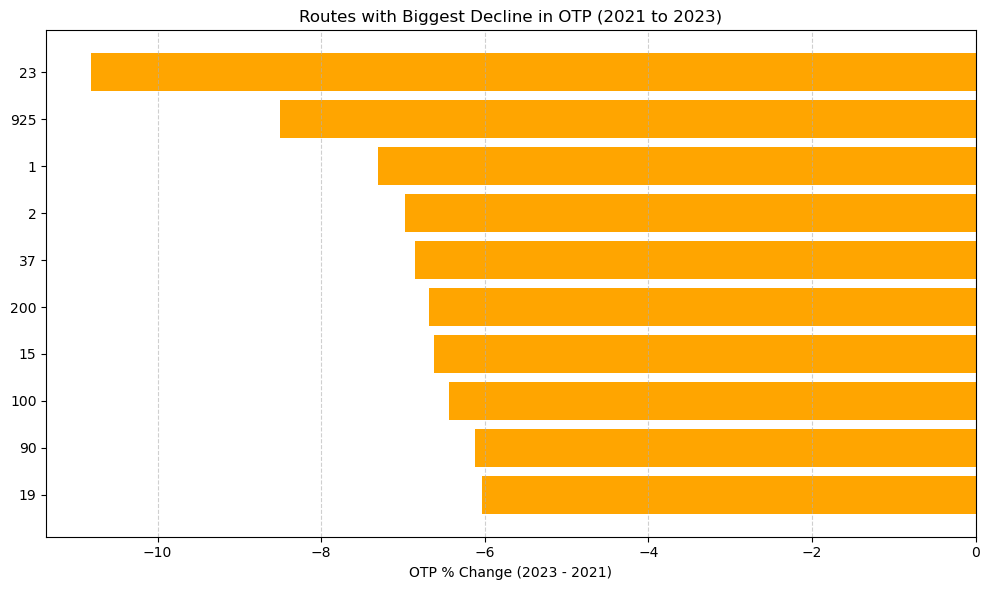

In [37]:
import matplotlib.pyplot as plt

# Drop rows with missing values in either 2021 or 2023 for clean plotting
otp_trend = otp_all_years_rounded.dropna(subset=['OTP_2021', 'OTP_2023'])

# Sort by biggest OTP % decline
biggest_declines = otp_trend.sort_values('Change_2021_2023').head(10)

# Plot bar chart of OTP % decline
plt.figure(figsize=(10, 6))
plt.barh(biggest_declines.index.astype(str), biggest_declines['Change_2021_2023'], color='orange')
plt.xlabel('OTP % Change (2023 - 2021)')
plt.title('Routes with Biggest Decline in OTP (2021 to 2023)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


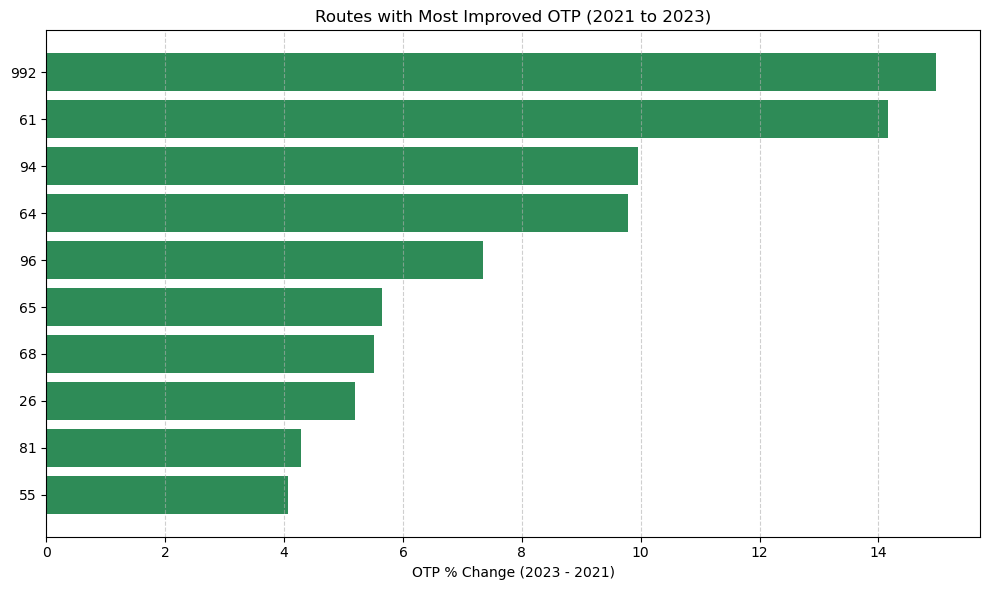

In [39]:
# Find the most improved routes: highest positive change from 2021 to 2023
most_improved = otp_trend.sort_values('Change_2021_2023', ascending=False).head(10)

# Plot bar chart of OTP % improvement
plt.figure(figsize=(10, 6))
plt.barh(most_improved.index.astype(str), most_improved['Change_2021_2023'], color='seagreen')
plt.xlabel('OTP % Change (2023 - 2021)')
plt.title('Routes with Most Improved OTP (2021 to 2023)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
